In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


FASE 1: LOAD DAN EKSPLORASI DATA

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

In [ ]:
# Load labels
df = pd.read_csv('/content/drive/MyDrive/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Labels.csv')
df['binary_label'] = (df['Label'] == 'GON+').astype(int)

In [ ]:
print(f"Total gambar : {len(df)}")

Total gambar : 747


In [ ]:
print(f"GON+ (Glaukoma): {(df['Label']=='GON+').sum()}")

GON+ (Glaukoma): 548


In [ ]:
print(f"GON- (Normal) : {(df['Label']=='GON-').sum()}")

GON- (Normal) : 199


In [ ]:
print(f"Quality Score : mean={df['Quality Score'].mean():.2f}")

Quality Score : mean=5.90


FASE 2: DATA UNDERSTANDING (EDA)

In [ ]:
# Setup
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11
BASE = '/content/drive/MyDrive/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0'
IMG_DIR = f'{BASE}/Images'

In [ ]:
df = pd.read_csv(f'{BASE}/Labels.csv')
df['binary_label'] = (df['Label'] == 'GON+').astype(int)
print(f"Total gambar : {len(df)}")
print(f"Unique patients : {df['Patient'].nunique()}")
print(f"GON+ (Glaukoma) : {(df['Label']=='GON+').sum()} ({100*(df['Label']=='GON+').mean():.1f}%)")
print(f"GON- (Normal) : {(df['Label']=='GON-').sum()} ({100*(df['Label']=='GON-').mean():.1f}%)")
print(f"Quality Score : min={df['Quality Score'].min():.1f}, max={df['Quality Score'].max():.1f}, mean={df['Quality Score'].mean():.2f}")

Total gambar : 747
Unique patients : 288
GON+ (Glaukoma) : 548 (73.4%)
GON- (Normal) : 199 (26.6%)
Quality Score : min=2.0, max=7.7, mean=5.90


VISUALISASI 1: Label Distribution

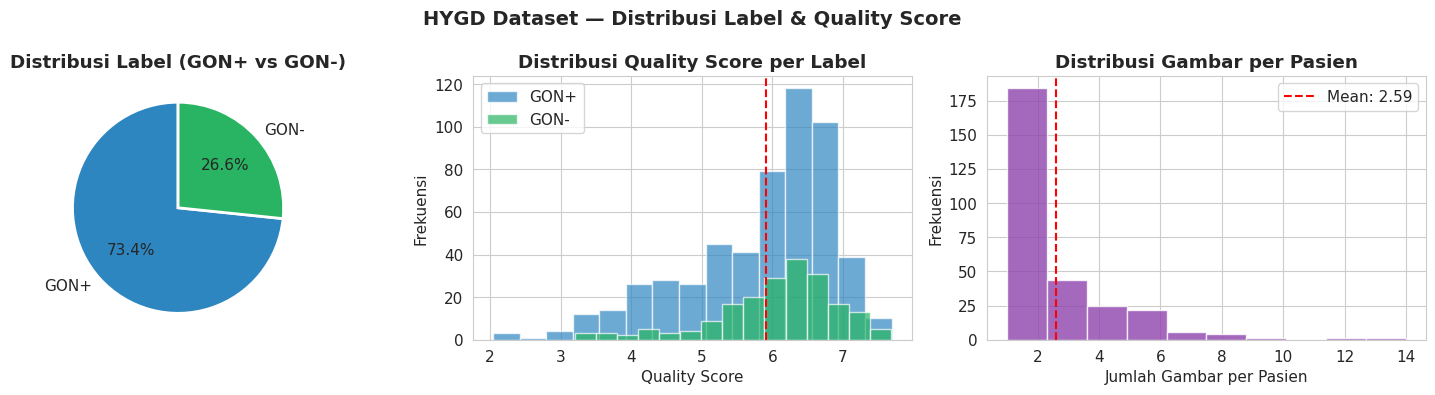

Gambar per pasien: min=1, max=14, mean=2.59


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('HYGD Dataset — Distribusi Label & Quality Score', fontsize=14, fontweight='bold')

# Pie chart
labels_count = df['Label'].value_counts()
colors_pie = ['#2E86C1', '#28B463']
axes[0].pie(labels_count.values, labels=labels_count.index,
autopct='%1.1f%%', colors=colors_pie, startangle=90,
wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribusi Label (GON+ vs GON-)', fontweight='bold')

# Quality Score histogram
axes[1].hist(df[df['Label']=='GON+']['Quality Score'], bins=15, alpha=0.7,
label='GON+', color='#2E86C1', edgecolor='white')
axes[1].hist(df[df['Label']=='GON-']['Quality Score'], bins=15, alpha=0.7,
label='GON-', color='#28B463', edgecolor='white')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Quality Score per Label', fontweight='bold')
axes[1].legend()
axes[1].axvline(df['Quality Score'].mean(), color='red', linestyle='--',
label=f'Mean: {df["Quality Score"].mean():.2f}')

# Images per patient
img_per_patient = df.groupby('Patient').size()
axes[2].hist(img_per_patient.values, bins=10, color='#8E44AD', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Jumlah Gambar per Pasien')
axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Gambar per Pasien', fontweight='bold')
axes[2].axvline(img_per_patient.mean(), color='red', linestyle='--',
label=f'Mean: {img_per_patient.mean():.2f}')
axes[2].legend()
plt.tight_layout()
os.makedirs('outputs/figures/', exist_ok=True)
plt.savefig('outputs/figures/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Gambar per pasien: min={img_per_patient.min()}, max={img_per_patient.max()}, mean={img_per_patient.mean():.2f}")

VISUALISASI 2: Sample Images GON+ vs GON-

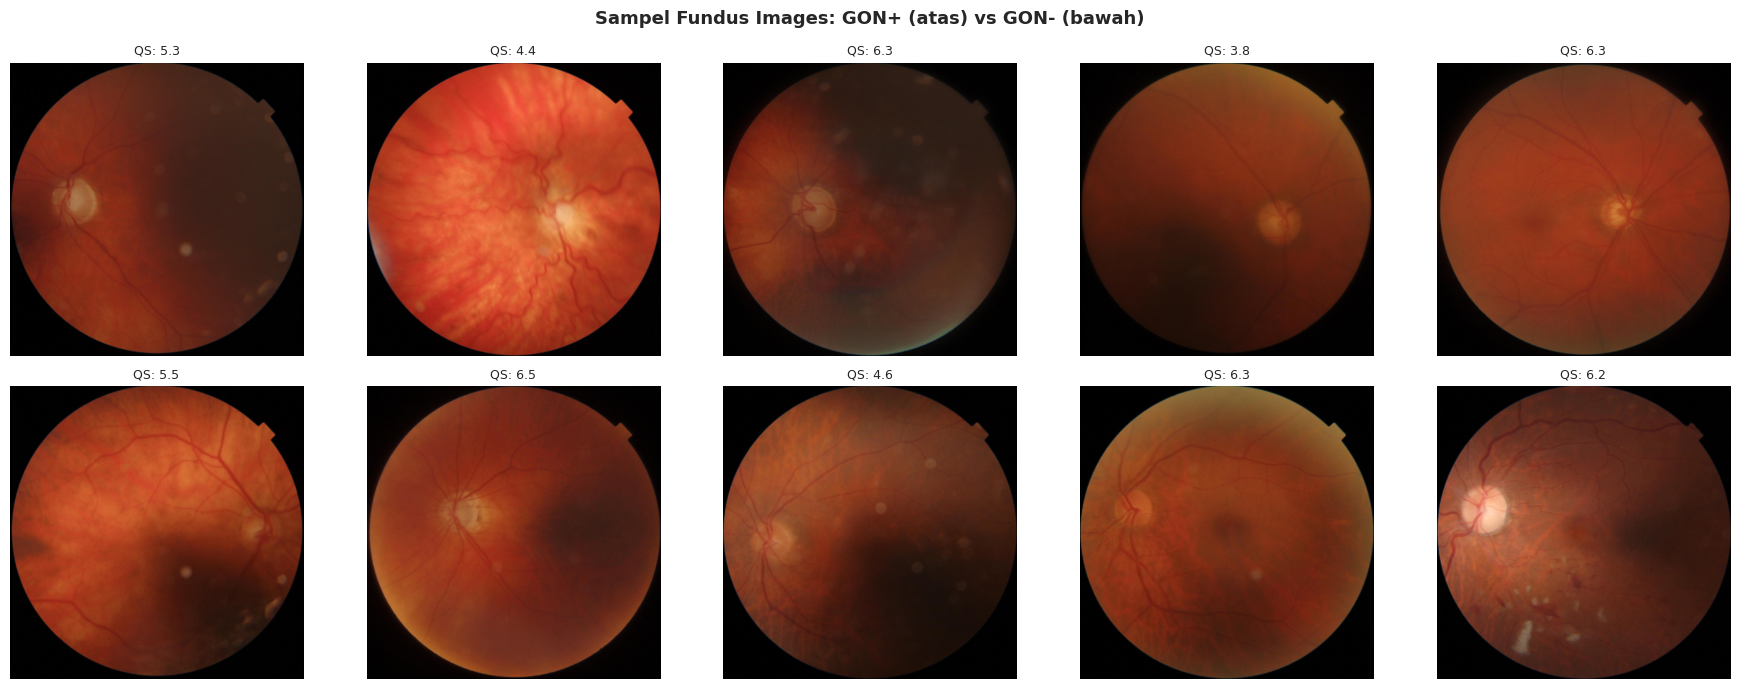

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Sampel Fundus Images: GON+ (atas) vs GON- (bawah)', fontsize=13, fontweight='bold')
for i, (label_class, label_name, row) in enumerate([
    ('GON+', 'Glaukoma (GON+)', 0),
    ('GON-', 'Normal (GON-)', 1)
]):
    samples = df[df['Label'] == label_class].sample(5, random_state=42)
    for j, (_, sample) in enumerate(samples.iterrows()):
        img = Image.open(os.path.join(IMG_DIR, sample['Image Name']))
        axes[row][j].imshow(img)
        qs = sample['Quality Score']
        axes[row][j].set_title(f"QS: {qs:.1f}", fontsize=9)
        axes[row][j].axis('off')
        if j == 0:
            axes[row][j].set_ylabel(label_name, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

VISUALISASI 3: Quality Score Analysis

/tmp/ipykernel_7535/1630804810.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qual_dist = df.groupby(['Label', 'quality_cat']).size().unstack(fill_value=0)


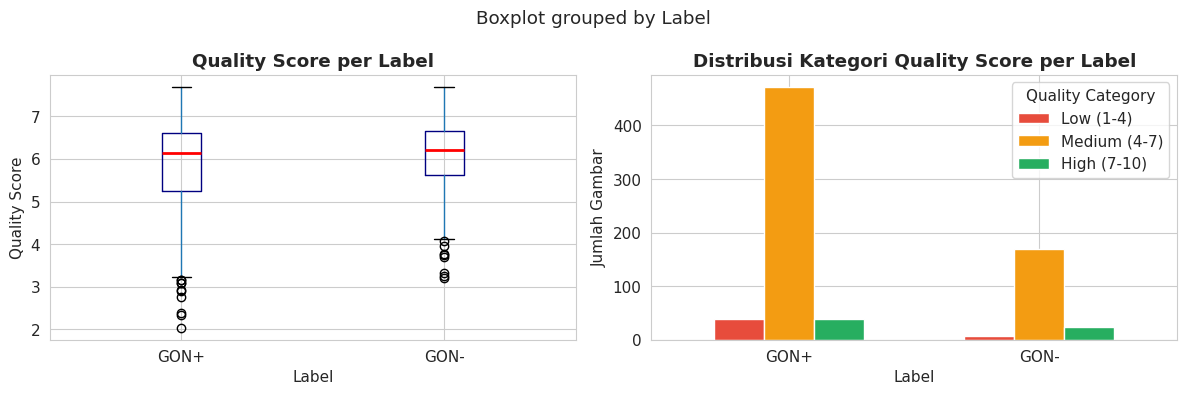

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Boxplot quality score per label
df.boxplot(column='Quality Score', by='Label', ax=axes[0],
boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Quality Score per Label', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Quality Score')

# Stacked bar: quality category per label
df['quality_cat'] = pd.cut(df['Quality Score'], bins=[0,4,7,10],
labels=['Low (1-4)', 'Medium (4-7)', 'High (7-10)'])
qual_dist = df.groupby(['Label', 'quality_cat']).size().unstack(fill_value=0)
qual_dist.plot(kind='bar', ax=axes[1], color=['#E74C3C','#F39C12','#27AE60'],
edgecolor='white', width=0.6)
axes[1].set_title('Distribusi Kategori Quality Score per Label', fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].legend(title='Quality Category')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('outputs/figures/03_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\nSTATISTIK DESKRIPTIF")
print(df.groupby('Label')['Quality Score'].describe().round(2))
print(f"\nImbalance ratio: {(df['Label']=='GON+').sum()/(df['Label']=='GON-').sum():.2f}:1")
print("Perlu stratified sampling atau class weighting!")


STATISTIK DESKRIPTIF
       count  mean   std   min   25%   50%   75%   max
Label                                                 
GON+   548.0  5.84  1.05  2.04  5.26  6.15  6.61  7.69
GON-   199.0  6.07  0.87  3.20  5.63  6.22  6.65  7.68

Imbalance ratio: 2.75:1
Perlu stratified sampling atau class weighting!


#Data Preparation

In [27]:
# Patient-level split (mencegah data leakage)

df = pd.read_csv('/content/drive/MyDrive/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Labels.csv')
df['binary_label'] = (df['Label'] == 'GON+').astype(int)
# Dapatkan label dominan per pasien (untuk stratified split)
patient_label = df.groupby('Patient')['binary_label'].agg(
lambda x: 1 if x.mean() >= 0.5 else 0
).reset_index()
patient_label.columns = ['Patient', 'patient_label']

# Stratified split berdasarkan PASIEN
train_patients, temp_patients = train_test_split(
patient_label['Patient'].values,
test_size=0.30,
random_state=42,
stratify=patient_label['patient_label'].values # jaga proporsi label
)
val_patients, test_patients = train_test_split(
temp_patients,
test_size=0.50,
random_state=42,
stratify=patient_label[patient_label['Patient'].isin(temp_patients)]['patient_label'].values
)

# Filter dataframe
train_df = df[df['Patient'].isin(train_patients)].reset_index(drop=True)
val_df = df[df['Patient'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['Patient'].isin(test_patients)].reset_index(drop=True)

# VERIFIKASI: tidak ada pasien yang overlap
assert len(set(train_patients) & set(val_patients)) == 0, "LEAKAGE DETECTED: train-val!"
assert len(set(train_patients) & set(test_patients)) == 0, "LEAKAGE DETECTED: train-test!"
assert len(set(val_patients) & set(test_patients)) == 0, "LEAKAGE DETECTED: val-test!"
print(f"Train: {len(train_df)} gambar {len(train_patients)} pasien")
print(f"Val : {len(val_df)} gambar {len(val_patients)} pasien")
print(f"Test : {len(test_df)} gambar {len(test_patients)} pasien")
print(f"Train GON+ ratio: {train_df['binary_label'].mean():.3f}")
print(f"Val GON+ ratio: {val_df['binary_label'].mean():.3f}")
print(f"Test GON+ ratio: {test_df['binary_label'].mean():.3f}")

# Simpan untuk reproducibility
os.makedirs('data/splits', exist_ok=True)
train_df.to_csv('data/splits/train_split.csv', index=False)
val_df.to_csv('data/splits/val_split.csv', index=False)
test_df.to_csv('data/splits/test_split.csv', index=False)
print("Splits disimpan ke data/splits/")

Train: 502 gambar 201 pasien
Val : 113 gambar 43 pasien
Test : 132 gambar 44 pasien
Train GON+ ratio: 0.723
Val GON+ ratio: 0.752
Test GON+ ratio: 0.758
Splits disimpan ke data/splits/


In [ ]:
# AUGMENTASI & PREPROCESSING

import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
from PIL import Image
import os

# Dataset Class dengan Optional CLAHE
class GlaucomaDataset(Dataset):
  def __init__(self, df, img_dir, transform=None, use_clahe=False):
    self.df = df
    self.img_dir = img_dir
    self.transform = transform
    self.use_clahe = use_clahe
  def __len__(self):
    return len(self.df)
  def apply_clahe(self, img_array):

# CLAHE: Enhance optic disc visibility
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = os.path.join(self.img_dir, row['Image Name'])
    image = Image.open(img_path).convert('RGB')
    if self.use_clahe:
      img_array = np.array(image)
      img_array = self.apply_clahe(img_array)
      image = Image.fromarray(img_array)
    label = torch.tensor(row['binary_label'], dtype=torch.long)
    qs = torch.tensor(row['Quality Score'], dtype=torch.float32)
    if self.transform:
      image = self.transform(image)
    return image, label, qs # return quality score untuk analisis


In [ ]:
from torchvision import transforms
import torch

# Transform Pipelines
# Training: augmentasi agresif
train_transform = transforms.Compose([
transforms.Resize((256, 256)), # resize sedikit lebih besar dulu
transforms.RandomCrop(224), # random crop ke 224
transforms.RandomHorizontalFlip(p=0.5),
transforms.RandomVerticalFlip(p=0.2), # fundus bisa diambil dari kanan/kiri
transforms.RandomRotation(degrees=20),
transforms.ColorJitter(
brightness=0.3, contrast=0.3,
saturation=0.2, hue=0.05
),
transforms.RandomGrayscale(p=0.05), # simulasi variasi kamera
transforms.ToTensor(),
transforms.Normalize(
mean=[0.485, 0.456, 0.406],
std=[0.229, 0.224, 0.225]
)
])

# Validation & Test: TIDAK ada augmentasi (hanya normalisasi)
eval_transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize(
mean=[0.485, 0.456, 0.406],
std=[0.229, 0.224, 0.225]
)
])
IMG_DIR = '/content/drive/MyDrive/hillel-yaffe-glaucoma-dataset-hygd-a-gold-standard-annotated-fundus-dataset-for-glaucoma-detection-1.0.0/Images'
BATCH = 32

# Hitung Class Weights
n_neg = (train_df['binary_label'] == 0).sum() # GON-
n_pos = (train_df['binary_label'] == 1).sum() # GON+
total = n_neg + n_pos

# Formula: weight[i] = total / (n_classes * count[i])
weight_neg = total / (2 * n_neg)
weight_pos = total / (2 * n_pos)
class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float)
print(f"Class weights: GON-={weight_neg:.3f}, GON+={weight_pos:.3f}")

# DataLoaders
train_set = GlaucomaDataset(train_df, IMG_DIR, train_transform, use_clahe=False)
val_set = GlaucomaDataset(val_df, IMG_DIR, eval_transform, use_clahe=False)
test_set = GlaucomaDataset(test_df, IMG_DIR, eval_transform, use_clahe=False)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=2,
pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"DataLoader siap: {len(train_loader)} train batches | {len(val_loader)} val batches")

Class weights: GON-=1.806, GON+=0.691
DataLoader siap: 16 train batches | 4 val batches


#FASE 4: MODELING

In [ ]:
import torch.nn as nn
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

# Build Model (Updated API, tanpa deprecation warning)
def build_model(arch='efficientnet_b0', num_classes=2, dropout=0.3):
  if arch == 'efficientnet_b0':
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
      nn.Dropout(p=dropout),
      nn.Linear(in_features, 256),
      nn.ReLU(),
      nn.Dropout(p=dropout/2),
      nn.Linear(256, num_classes)
    )

  elif arch == 'resnet50':
    from torchvision.models import ResNet50_Weights
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
      nn.Dropout(p=dropout),
      nn.Linear(in_features, num_classes)
    )
  return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
model = build_model('efficientnet_b0').to(device)

# Hitung total parameters
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {train_params:,}")

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.AdamW(
model.parameters(), lr=1e-3, weight_decay=1e-4, amsgrad=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
optimizer, T_max=30, eta_min=1e-6
)

Device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.3MB/s]


Total params: 4,335,998 | Trainable: 4,335,998


In [ ]:
# Training & Evaluation Functions
def train_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss, correct, total = 0, 0, 0
  for imgs, labels, qs in loader:
    imgs, labels = imgs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping
    optimizer.step()
    total_loss += loss.item()
    _, predicted = outputs.max(1)
    correct += predicted.eq(labels).sum().item()
    total += labels.size(0)
  return total_loss / len(loader), 100. * correct / total
def evaluate(model, loader, device):
  from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
  model.eval()
  all_labels, all_probs, all_preds = [], [], []
  with torch.no_grad():
    for imgs, labels, qs in loader:
      imgs = imgs.to(device)
      outputs = model(imgs)
      probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
      preds = outputs.argmax(dim=1).cpu().numpy()
      all_probs.extend(probs)
      all_preds.extend(preds)
      all_labels.extend(labels.numpy())
  auc = roc_auc_score(all_labels, all_probs)
  acc = accuracy_score(all_labels, all_preds)
  return auc, acc, all_labels, all_probs, all_preds

In [ ]:
# Main Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_auc': [], 'val_acc': [], 'lr': []}
best_auc = 0
PATIENCE, patience_count = 7, 0
for epoch in range(30):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_auc, val_acc, *_ = evaluate(model, val_loader, device)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_auc'].append(val_auc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    status = ""
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_auc': val_auc}, 'outputs/best_model.pth')
        status = f" -> BEST MODEL SAVED"
        patience_count = 0
    else:
        patience_count += 1
    print(f"Epoch {epoch+1:2d}/{30} | Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.1f}% | Val AUC: {val_auc:.4f} | "
          f"Val Acc: {val_acc*100:.1f}% | LR: {current_lr:.2e}{status}")
    if patience_count >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break
print(f"\nBest Validation AUC: {best_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  1/30 | Loss: 0.4790 | Train Acc: 83.7% | Val AUC: 0.9979 | Val Acc: 98.2% | LR: 1.00e-03 -> BEST MODEL SAVED


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  2/30 | Loss: 0.2417 | Train Acc: 92.2% | Val AUC: 0.9895 | Val Acc: 91.2% | LR: 9.97e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch 11/30 | Loss: 0.1640 | Train Acc: 94.8% | Val AUC: 1.0000 | Val Acc: 99.1% | LR: 7.50e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 12/30 | Loss: 0.1072 | Train Acc: 97.2% | Val AUC: 1.0000 | Val Acc: 99.1% | LR: 7.04e-04


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 13/30 | Loss: 0.0730 | Train Acc: 96.8% | Val AUC: 1.0000 | Val Acc: 99.1% | LR: 6.55e-04
Early stopping triggered at epoch 13

Best Validation AUC: 1.0000


 # FASE 5: EVALUATION

In [26]:
# EVALUASI FINAL AND INTERPRETABILITY (GRAD-CAM)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
recall_score, f1_score, confusion_matrix,
roc_curve, matthews_corrcoef, classification_report)
import torch
import cv2

# Load best model
checkpoint = torch.load('outputs/best_model.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
print(f"Model dimuat dari epoch {checkpoint['epoch']+1}, Val AUC: {checkpoint['val_auc']:.4f}")

# Evaluasi TEST SET
model.eval()
all_labels, all_probs, all_preds = [], [], []
with torch.no_grad():
  for imgs, labels, qs in test_loader:
    imgs = imgs.to(device)
    probs = torch.softmax(model(imgs), dim=1)[:, 1].cpu().numpy()
    preds = (probs >= 0.5).astype(int)
    all_probs.extend(probs)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# Hitung semua metrik
auc = roc_auc_score(all_labels, all_probs)
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp)
print("HASIL EVALUASI TEST SET")
print(f"AUC-ROC : {auc:.4f}")
print(f"Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print(f"Sensitivity : {rec:.4f} ({rec*100:.1f}%) <- PRIORITAS KLINIS")
print(f"Specificity : {spec:.4f} ({spec*100:.1f}%)")
print(f"Precision : {prec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"MCC : {mcc:.4f}")
print(f"TP:{tp} | TN:{tn} | FP:{fp} | FN:{fn}")
print(f"\nFalse Negatives (missed glaucoma): {fn} pasien!")
print(classification_report(all_labels, all_preds,
target_names=['GON- (Normal)', 'GON+ (Glaukoma)']))

Model dimuat dari epoch 6, Val AUC: 1.0000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


HASIL EVALUASI TEST SET
AUC-ROC : 0.9925
Accuracy : 0.9697 (97.0%)
Sensitivity : 0.9700 (97.0%) <- PRIORITAS KLINIS
Specificity : 0.9688 (96.9%)
Precision : 0.9898
F1-Score : 0.9798
MCC : 0.9200
TP:97 | TN:31 | FP:1 | FN:3

False Negatives (missed glaucoma): 3 pasien!
                 precision    recall  f1-score   support

  GON- (Normal)       0.91      0.97      0.94        32
GON+ (Glaukoma)       0.99      0.97      0.98       100

       accuracy                           0.97       132
      macro avg       0.95      0.97      0.96       132
   weighted avg       0.97      0.97      0.97       132



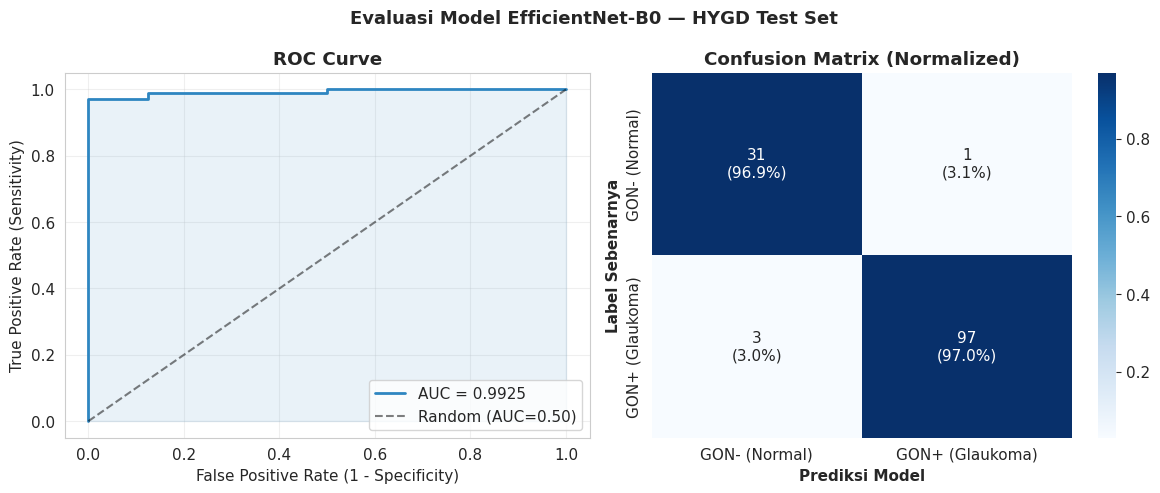

In [ ]:
# VISUALISASI: ROC Curve and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Evaluasi Model EfficientNet-B0 — HYGD Test Set', fontweight='bold', fontsize=13)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='#2E86C1', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2E86C1')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)
import seaborn as sns
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=[[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})'
for j in range(2)] for i in range(2)],
fmt='', cmap='Blues', ax=axes[1],
xticklabels=['GON- (Normal)','GON+ (Glaukoma)'],
yticklabels=['GON- (Normal)','GON+ (Glaukoma)'])
axes[1].set_ylabel('Label Sebenarnya', fontweight='bold')
axes[1].set_xlabel('Prediksi Model', fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


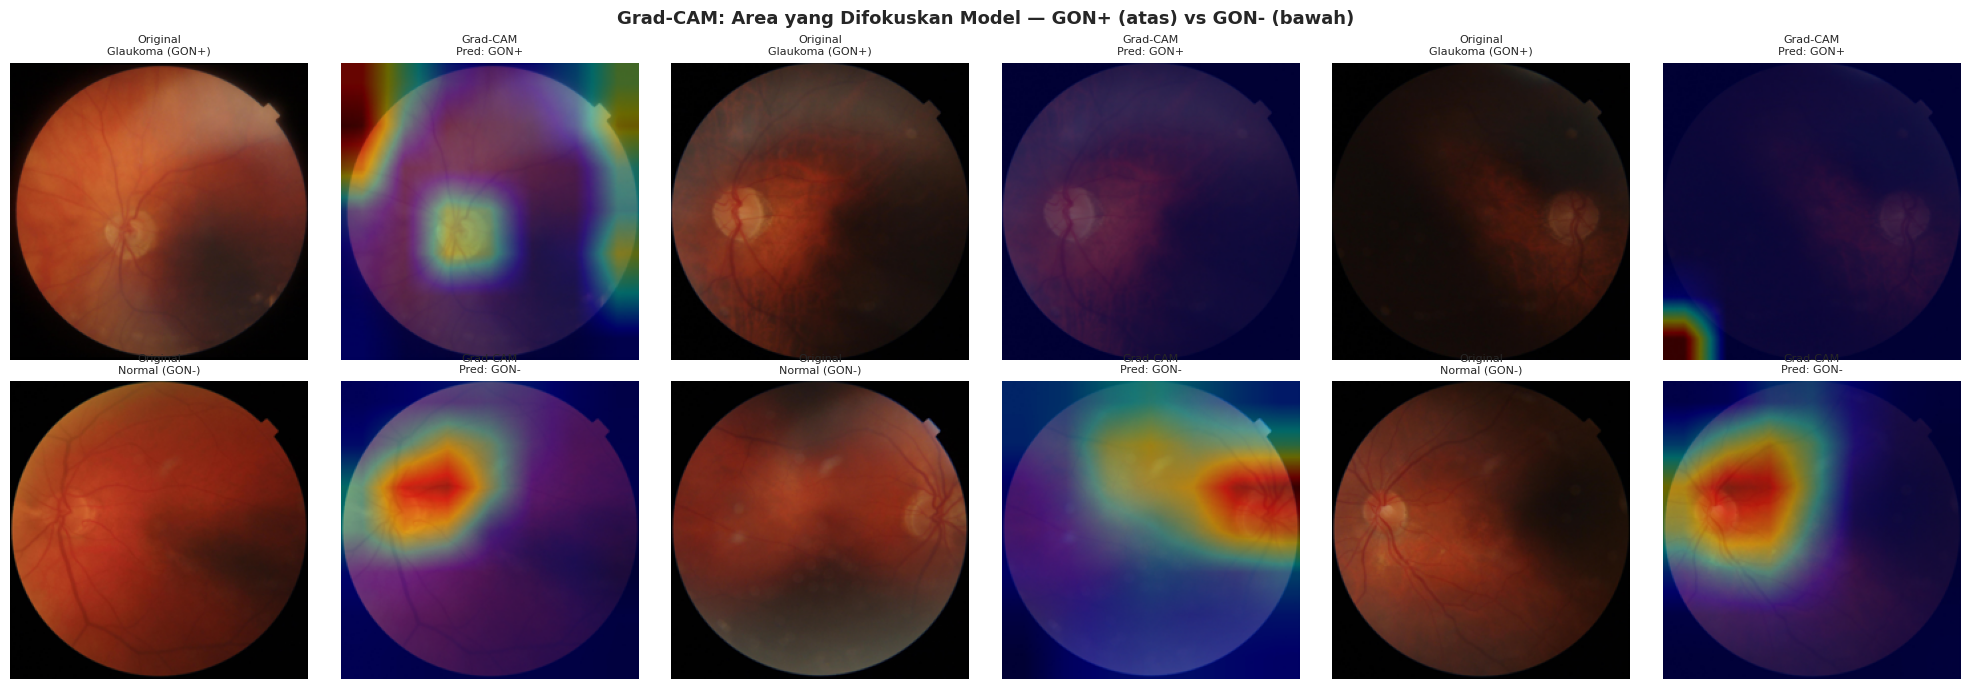

In [ ]:
# GRAD-CAM IMPLEMENTATION
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx

# Target layer EfficientNet-B0: features[-1]
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

# Visualisasi Grad-CAM untuk sampel test
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    return (tensor * std[:, None, None] + mean[:, None, None]).clamp(0,1)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Grad-CAM: Area yang Difokuskan Model = GON+ (atas) vs GON- (bawah)',
            fontweight='bold', fontsize=13)

for row_idx, target_label in enumerate([1, 0]): # 1=GON+, 0=GON-
    label_name = "Glaukoma (GON+)" if target_label == 1 else "Normal (GON-)"
    indices = [i for i, l in enumerate(all_labels) if l == target_label][:3]

    for col_idx, sample_idx in enumerate(indices):
        # Get original image
        img_path = os.path.join(IMG_DIR, test_df.iloc[sample_idx]['Image Name'])
        orig_img = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))

        # Get test sample
        sample = test_set[sample_idx]
        input_tensor = sample[0].unsqueeze(0).to(device)

        model.eval()
        cam, pred_class = gradcam.generate(input_tensor, class_idx=target_label)

        # Original
        axes[row_idx][col_idx*2].imshow(orig_img)
        axes[row_idx][col_idx*2].set_title(f'Original\n{label_name}', fontsize=8)
        axes[row_idx][col_idx*2].axis('off')

        # Grad-CAM overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(orig_img, 0.6, heatmap, 0.4, 0)
        axes[row_idx][col_idx*2+1].imshow(overlay)
        pred_name = "GON+" if pred_class == 1 else "GON-"
        axes[row_idx][col_idx*2+1].set_title(f'Grad-CAM\nPred: {pred_name}', fontsize=8)
        axes[row_idx][col_idx*2+1].axis('off')

plt.tight_layout()
plt.savefig('outputs/figures/06_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()

PERFORMA MODEL PER KATEGORI QUALITY SCORE
Low (1-4): n=7, Accuracy=0.857, AUC=1.000
Medium (4-7): n=117, Accuracy=0.974, AUC=0.993
High (7-10): n=8, Accuracy=1.000, AUC=1.000


/tmp/ipykernel_7535/511547340.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quality_acc = test_df_eval.groupby('quality_cat')['correct'].mean()


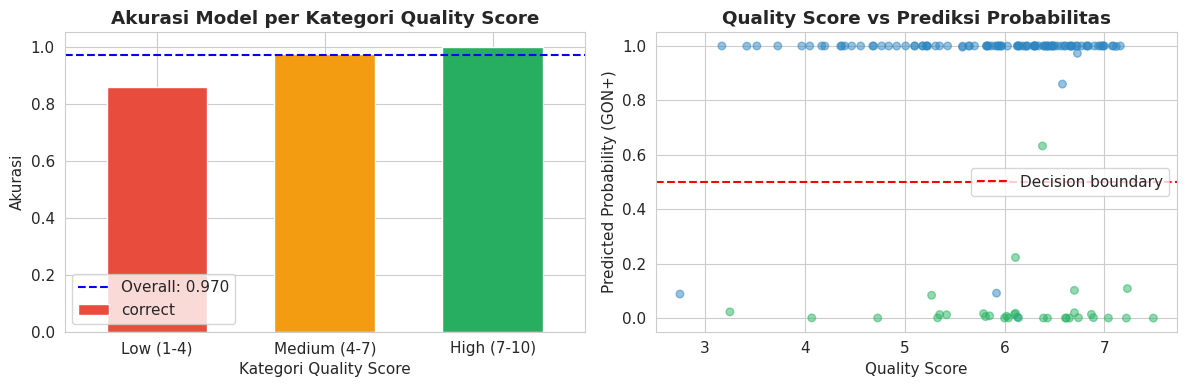

In [25]:
# ANALISIS QUALITY-AWARE
test_df_eval = test_df.copy()
test_df_eval['pred_prob'] = all_probs
test_df_eval['pred_class'] = all_preds
test_df_eval['correct'] = (test_df_eval['pred_class'] == test_df_eval['binary_label']).astype(int)

# Bagi gambar berdasarkan quality score
test_df_eval['quality_cat'] = pd.cut(
    test_df_eval['Quality Score'],
    bins=[0, 4, 7, 10],
    labels=['Low (1-4)', 'Medium (4-7)', 'High (7-10)']
)

# Evaluasi per kategori quality
print("PERFORMA MODEL PER KATEGORI QUALITY SCORE")
for cat in ['Low (1-4)', 'Medium (4-7)', 'High (7-10)']:
    subset = test_df_eval[test_df_eval['quality_cat'] == cat]
    if len(subset) > 5:
        cat_acc = subset['correct'].mean()
        cat_auc = roc_auc_score(subset['binary_label'], subset['pred_prob'])
        print(f"{cat}: n={len(subset)}, Accuracy={cat_acc:.3f}, AUC={cat_auc:.3f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Akurasi per quality category
quality_acc = test_df_eval.groupby('quality_cat')['correct'].mean()
quality_acc.plot(kind='bar', ax=axes[0], color=['#E74C3C','#F39C12','#27AE60'],
                 edgecolor='white', width=0.6)
axes[0].set_title('Akurasi Model per Kategori Quality Score', fontweight='bold')
axes[0].set_ylabel('Akurasi')
axes[0].set_xlabel('Kategori Quality Score')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(acc, color='blue', linestyle='--', label=f'Overall: {acc:.3f}')
axes[0].legend()

# Scatter: quality score vs prediction probability
colors_scatter = ['#2E86C1' if l == 1 else '#28B463'
                  for l in test_df_eval['binary_label']]
axes[1].scatter(test_df_eval['Quality Score'], test_df_eval['pred_prob'],
                c=colors_scatter, alpha=0.5, s=30)
axes[1].axhline(0.5, color='red', linestyle='--', label='Decision boundary')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Predicted Probability (GON+)')
axes[1].set_title('Quality Score vs Prediksi Probabilitas', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/07_quality_aware.png', dpi=150, bbox_inches='tight')
plt.show()